## Teste Z
Máquina fabrica perfumes com média μ = 150 ml e desvio padrão 𝜎 = 2 ml. Uma amostra aleatória de 100 frascos de perfume é colhida e observa-se uma média de 150,2 ml. A máquina está operando corretamente (confiança = 95%)?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats import weightstats

Vamos agora plotar a distribuição desses dados usando displot.

In [4]:
df = pd.read_csv('Machine1.csv')
df

,Machine 1
0,152.63
1,152.94
2,151.29
3,153.44
4,148.58
...,...
95,150.03
96,146.79
97,150.02
98,146.42


In [3]:
df.describe()

,Machine 1
count,100.000000
mean,150.203100
std,2.018812
min,145.550000
25%,148.717500
50%,150.285000
75%,151.502500
max,154.550000


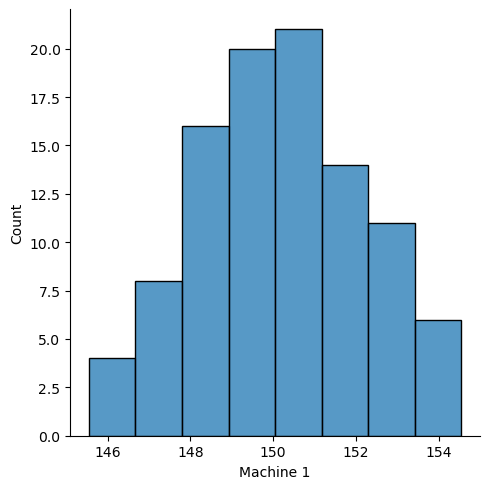

In [5]:
sns.displot(data = df, x = "Machine 1")

Vamos plotar um boxplot dos nossos dados.

<Axes: >

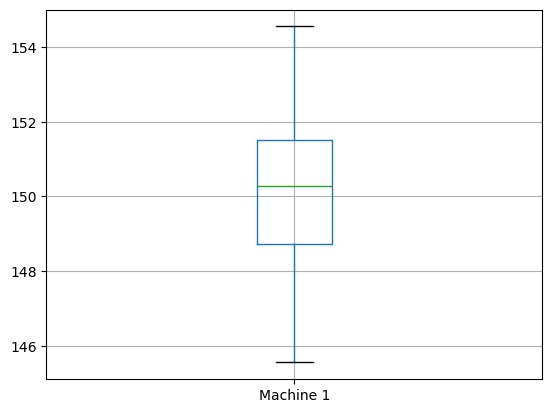

In [6]:
df.boxplot(column=['Machine 1'])

Para realizar nosso teste de hipótese (Teste Z) vamos usar weightstats.

H0: μ = 150 ml \
HA: μ <> 150 ml

In [ ]:
weightstats.ztest(x1=df['Machine 1'], value=150, alternative='two-sided')
# 1° valor = z-cal; 2° valor = p-value

(np.float64(1.0060370247722599), np.float64(0.3143977600779597))

Conclusão: Tendo em vista que pValue = 0.31 (portanto maior que 0.05), falhamos em rejeitar a hipotese nula. Logo, a máquina está operando corretamente.

## Teste t
Máquina fabrica perfumes com média μ = 150 ml. Uma amostra aleatória de 4 frascos de perfume é colhida e observa-se uma média de 151 ml e um desvio padrão amostral s = 2 ml. A máquina está operando corretamente (confiança = 95%)?

H0: μ = 150 ml \
HA: μ <> 150 ml

Vamos começar gerando as 4 amostras.

In [12]:
volume = pd.Series([148.5, 153.4, 150.9, 151.2]) #criando a amostra de 4 dados
volume

0    148.5
1    153.4
2    150.9
3    151.2
dtype: float64

In [13]:
volume.describe()

count      4.000000
mean     151.000000
std        2.004994
min      148.500000
25%      150.300000
50%      151.050000
75%      151.750000
max      153.400000
dtype: float64

Vamos agora realizar o Teste t.

In [14]:
stats.ttest_1samp(volume, 150) #teste t para amostra única
# 1° valor = t-cal; 2° valor = p-value; 3° valor = degrees of freedom (n-1)

TtestResult(statistic=np.float64(0.997509336107632), pvalue=np.float64(0.3920333832606524), df=np.int64(3))

Conclusão: Tendo em vista que pValue = 0.39 (maior que 0.05), falhamos em rejeitar a hipotese nula. Logo, a máquina está operando corretamente.

Exercício 1 \
Suponha que uma máquina envase garrafas de vinho com média 750 ml e desvio padrão desconhecido. A vinícola decidiu realizar um teste de hipótese com erro alfa = 0,05 e duas caudas. Para tanto, escolheu 4 amostras do arquivo Machine2.csv. Realize o teste t e informe se a máquina está operando corretamente (hipótese nula).

H0: μ = 750 ml
Ha: μ ≠ 750 ml

In [16]:
df2 = pd.read_csv('Machine2.csv')  
df4 = df2.head(4)
df4

,Machine 2
0,794.21
1,781.35
2,736.66
3,745.22


In [17]:
stats.ttest_1samp(df4['Machine 2'], 750)

TtestResult(statistic=np.float64(1.0342557374997143), pvalue=np.float64(0.3770787757509829), df=np.int64(3))

Conclusão: Visto que pValue = 0.37 > 0.05, falhamos em rejeitar a hipotese nula. Logo, a máquina está operando corretamente.

Exercício 2 \
Suponha que o desvio padrão da máquina seja conhecido (15 ml). Realize um teste Z com as 50 amostras disponíveis no arquivo 'machine2.csv'.

In [23]:
df50 = df2.head(50)
weightstats.ztest(x1=df50['Machine 2'], value=750, alternative="two-sided")


(np.float64(0.9804661150943946), np.float64(0.32685608794791343))

Conclusão: Visto que pValue = 0.32 > 0.05, falhamos em rejeitar a hipotese nula. Logo, a máquina está funcionando corretamente.